<a href="https://colab.research.google.com/github/jayw20230711/AI-DataSets/blob/main/PyTorch_Deep_Learning%5B1%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Deep Learning with PyTorch — Basic to Advanced
> **Google Colab Ready** | GPU-accelerated | 6 Chapters · 13 Examples

**How to use this notebook:**
1. `Runtime → Change runtime type → T4 GPU` ✅
2. `Runtime → Run all` or step through cells with `Shift+Enter`


## ⚙️ Setup & GPU Check

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU')


PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


---
# Chapter 1 — Tensors & Autograd
> *The foundation of every PyTorch program*

### 1.1 Creating & Manipulating Tensors

In [2]:
# Scalar, vector, matrix
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.zeros(3, 4)
rand   = torch.randn(4, 4)

# From NumPy
arr = np.array([1, 2, 3])
t   = torch.from_numpy(arr)

# Device placement
t_gpu = rand.to(device)

print('scalar shape:', scalar.shape)
print('vector shape:', vector.shape)
print('matrix dtype:', matrix.dtype)
print('rand on device:', t_gpu.device)


scalar shape: torch.Size([])
vector shape: torch.Size([3])
matrix dtype: torch.float32
rand on device: cuda:0


### 1.2 Tensor Operations

In [3]:
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[5., 6.], [7., 8.]])

print('Element-wise add:\n', a + b)
print('Matrix multiply:\n', a @ b)
print('Mean over rows:', a.mean(dim=0))

# Reshaping
c = torch.arange(12.)
print('Reshaped 3x4:\n', c.view(3, 4))
print('Transpose:\n', a.T)


Element-wise add:
 tensor([[ 6.,  8.],
        [10., 12.]])
Matrix multiply:
 tensor([[19., 22.],
        [43., 50.]])
Mean over rows: tensor([2., 3.])
Reshaped 3x4:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
Transpose:
 tensor([[1., 3.],
        [2., 4.]])


### 1.3 Autograd — Automatic Differentiation

In [4]:
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Forward pass: y = w*x^2 + b
y = w * x**2 + b

# Backward pass
y.backward()

# dy/dx = 2*w*x = 12
# dy/dw = x^2  = 4
# dy/db = 1
print(f'y       = {y.item()}')
print(f'x.grad  = {x.grad}  (expected 12)')
print(f'w.grad  = {w.grad}  (expected 4)')
print(f'b.grad  = {b.grad}  (expected 1)')


y       = 13.0
x.grad  = 12.0  (expected 12)
w.grad  = 4.0  (expected 4)
b.grad  = 1.0  (expected 1)


---
# Chapter 2 — Neural Networks with nn.Module
> *Building and training your first networks*

### 2.1 Linear Regression from Scratch

Learned: y = 1.997x + 1.006  (target: y = 2.0x + 1.0)


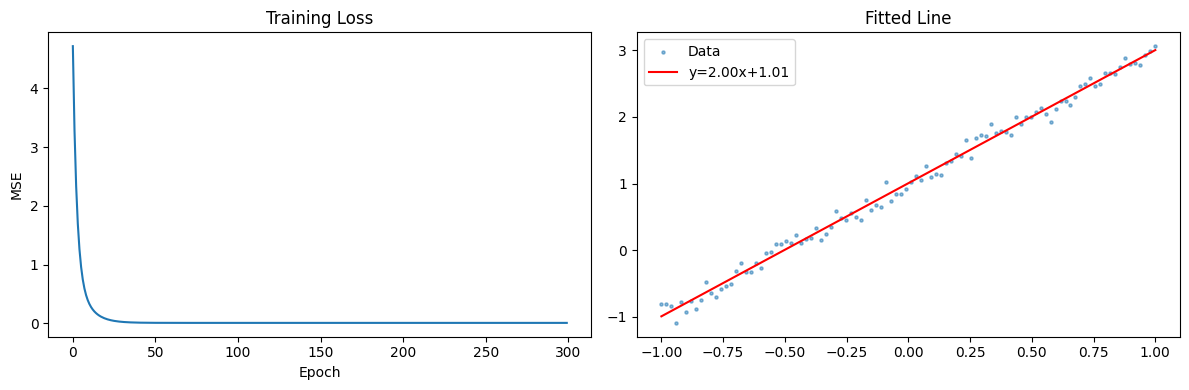

In [5]:
torch.manual_seed(42)
X = torch.linspace(-1, 1, 100).unsqueeze(1)
y = 2 * X + 1 + 0.1 * torch.randn(100, 1)

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)
    def forward(self, x):
        return self.fc(x)

model     = LinearRegression().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
X, y      = X.to(device), y.to(device)

losses = []
for epoch in range(300):
    pred = model(X)
    loss = criterion(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

w = model.fc.weight.item()
b = model.fc.bias.item()
print(f'Learned: y = {w:.3f}x + {b:.3f}  (target: y = 2.0x + 1.0)')

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(losses); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.subplot(1,2,2)
X_cpu = X.cpu(); y_cpu = y.cpu()
plt.scatter(X_cpu, y_cpu, s=5, alpha=0.5, label='Data')
plt.plot(X_cpu.detach(), model(X).cpu().detach(), 'r', label=f'y={w:.2f}x+{b:.2f}')
plt.legend(); plt.title('Fitted Line')
plt.tight_layout(); plt.show()


### 2.2 MLP on MNIST

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('/tmp/data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('/tmp/data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

model     = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

def evaluate(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item(); total += len(y)
    return correct / total

for epoch in range(5):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    acc = evaluate(model, test_loader)
    print(f'Epoch {epoch+1}/5 | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 461kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]

Parameters: 235,146


Epoch 1/5 | Loss: 0.3839 | Test Acc: 0.9523
Epoch 2/5 | Loss: 0.1548 | Test Acc: 0.9671
Epoch 3/5 | Loss: 0.1130 | Test Acc: 0.9743
Epoch 4/5 | Loss: 0.0901 | Test Acc: 0.9757
Epoch 5/5 | Loss: 0.0742 | Test Acc: 0.9747


---
# Chapter 3 — Convolutional Neural Networks (CNNs)
> *Spatial feature learning for images*

### 3.1 CNN on MNIST

CNN Parameters: 1,676,458
Epoch 1/5 | Loss: 0.2049 | Test Acc: 0.9870
Epoch 2/5 | Loss: 0.0618 | Test Acc: 0.9907
Epoch 3/5 | Loss: 0.0461 | Test Acc: 0.9931
Epoch 4/5 | Loss: 0.0295 | Test Acc: 0.9946
Epoch 5/5 | Loss: 0.0259 | Test Acc: 0.9946


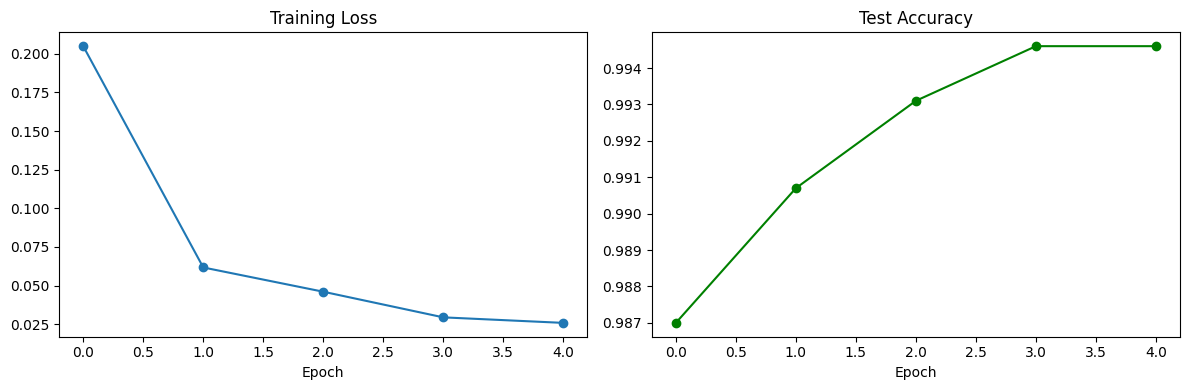

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

model     = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
print(f'CNN Parameters: {sum(p.numel() for p in model.parameters()):,}')

train_losses, test_accs = [], []
for epoch in range(5):
    model.train(); total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    acc = evaluate(model, test_loader)
    scheduler.step()
    train_losses.append(total_loss/len(train_loader))
    test_accs.append(acc)
    print(f'Epoch {epoch+1}/5 | Loss: {train_losses[-1]:.4f} | Test Acc: {acc:.4f}')

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(train_losses, marker='o'); plt.title('Training Loss'); plt.xlabel('Epoch')
plt.subplot(1,2,2); plt.plot(test_accs, marker='o', color='green'); plt.title('Test Accuracy'); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()


### 3.2 Visualize CNN Filters & Feature Maps

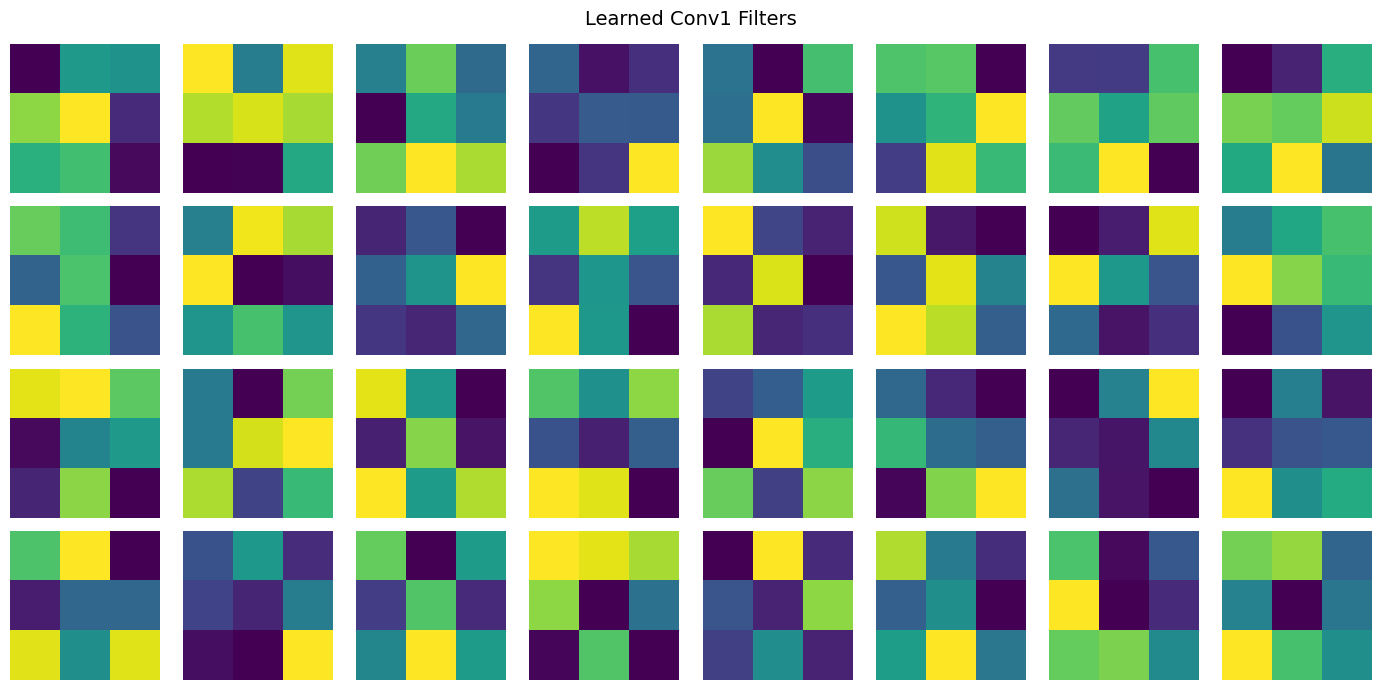

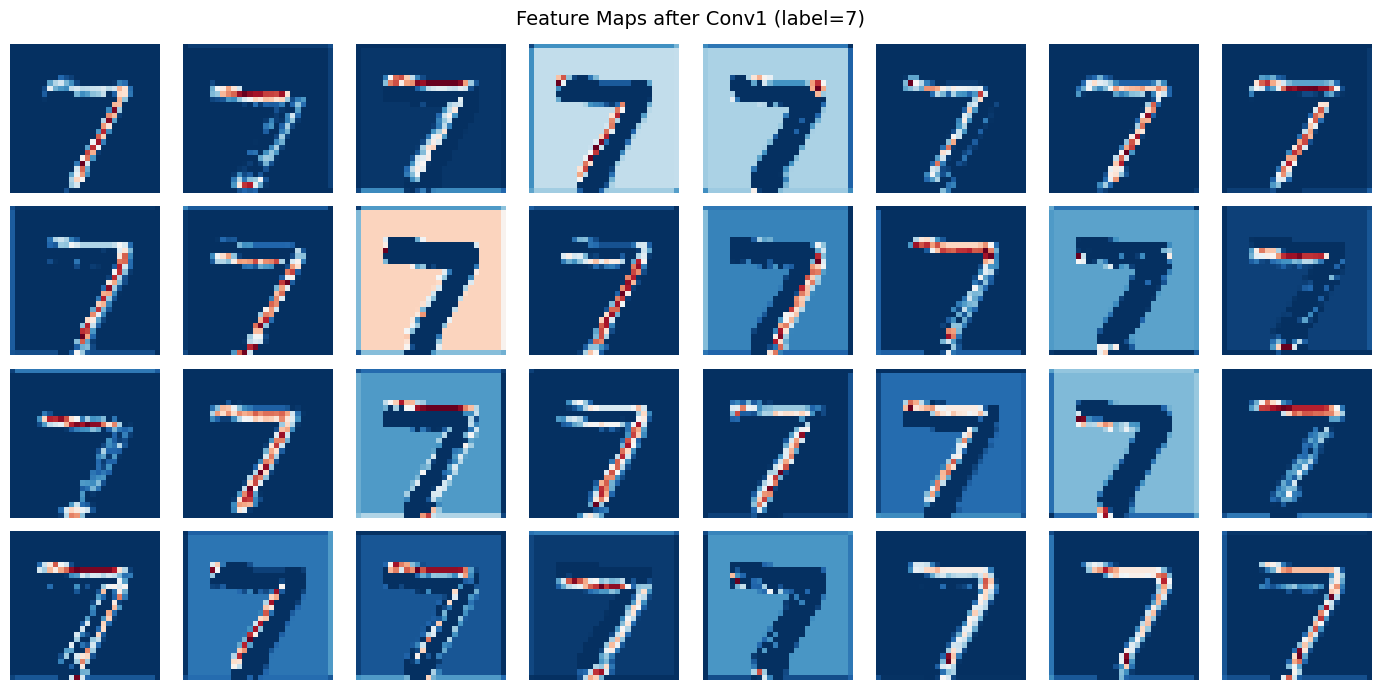

In [8]:
# Visualize learned filters from first conv layer
filters = model.features[0].weight.data.cpu()
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        ax.imshow(filters[i, 0], cmap='viridis')
    ax.axis('off')
plt.suptitle('Learned Conv1 Filters', fontsize=14)
plt.tight_layout(); plt.show()

# Visualize feature maps for one test image
model.eval()
sample, label = test_ds[0]
with torch.no_grad():
    x = sample.unsqueeze(0).to(device)
    feat = model.features[:3](x).squeeze().cpu()  # after first conv+bn+relu

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < feat.shape[0]:
        ax.imshow(feat[i], cmap='RdBu_r')
    ax.axis('off')
plt.suptitle(f'Feature Maps after Conv1 (label={label})', fontsize=14)
plt.tight_layout(); plt.show()


---
# Chapter 4 — LSTMs & Sequence Modeling
> *Recurrent networks for sequential data*

### 4.1 Bidirectional LSTM Text Classifier

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        attn = torch.softmax(self.attention(out), dim=1)
        context = (out * attn).sum(dim=1)
        return self.fc(self.dropout(context))

model = LSTMClassifier(10000, 128, 256, 2, 3).to(device)
x = torch.randint(0, 10000, (32, 50)).to(device)
print('Output shape:', model(x).shape)  # [32, 3]
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Output shape: torch.Size([32, 3])
Parameters: 3,649,540


### 4.2 Time Series Forecasting with LSTM

/tmp/ipykernel_770/1608415264.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.FloatTensor(X).unsqueeze(-1), torch.FloatTensor(y)


Epoch 10: train=0.9476 val=0.9235
Epoch 20: train=0.6847 val=0.6438
Epoch 30: train=0.4904 val=0.4553


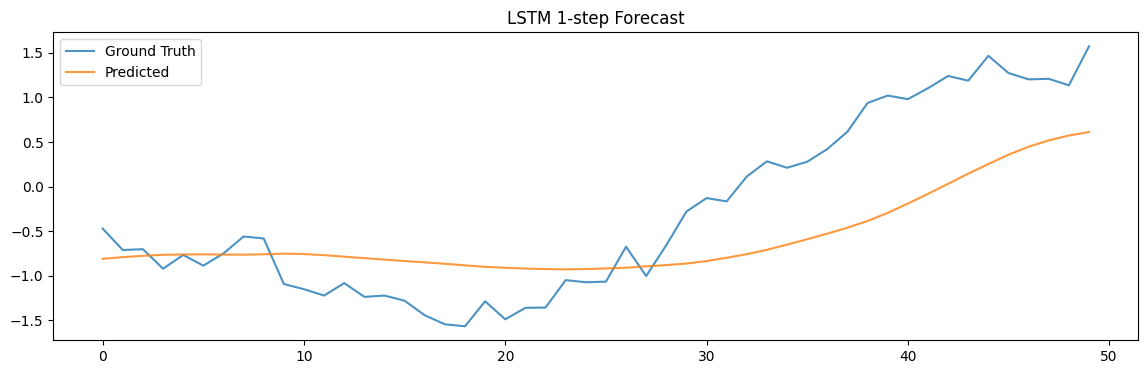

In [10]:
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden=64, layers=2, horizon=7):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden, horizon)
        self.hidden, self.layers = hidden, layers

    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden).to(x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

def create_sequences(data, window=30, horizon=7):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+horizon])
    return torch.FloatTensor(X).unsqueeze(-1), torch.FloatTensor(y)

# Synthetic multi-frequency signal
t = np.linspace(0, 100, 2000)
signal = np.sin(t) + 0.5*np.sin(3*t) + 0.1*np.random.randn(2000)
signal = (signal - signal.mean()) / signal.std()  # normalize

X, y = create_sequences(signal)
split = int(0.8 * len(X))
X_tr, y_tr = X[:split].to(device), y[:split].to(device)
X_te, y_te = X[split:].to(device), y[split:].to(device)

ts_model   = TimeSeriesLSTM().to(device)
ts_optim   = torch.optim.Adam(ts_model.parameters(), lr=1e-3)
ts_crit    = nn.MSELoss()

for epoch in range(30):
    ts_model.train()
    ts_optim.zero_grad()
    loss = ts_crit(ts_model(X_tr), y_tr)
    loss.backward(); ts_optim.step()
    if (epoch+1) % 10 == 0:
        ts_model.eval()
        with torch.no_grad():
            val_loss = ts_crit(ts_model(X_te), y_te)
        print(f'Epoch {epoch+1}: train={loss.item():.4f} val={val_loss.item():.4f}')

# Plot predictions
ts_model.eval()
with torch.no_grad():
    preds = ts_model(X_te[:50]).cpu().numpy()
    truth = y_te[:50].cpu().numpy()
plt.figure(figsize=(14,4))
plt.plot(truth[:, 0], label='Ground Truth', alpha=0.8)
plt.plot(preds[:, 0], label='Predicted',   alpha=0.8)
plt.title('LSTM 1-step Forecast'); plt.legend(); plt.show()


---
# Chapter 5 — Transformers from Scratch
> *Attention mechanisms & modern architectures*

### 5.1 Scaled Dot-Product & Multi-Head Attention

Output shape      : torch.Size([2, 10, 256])
Attention weights : torch.Size([2, 8, 10, 10])


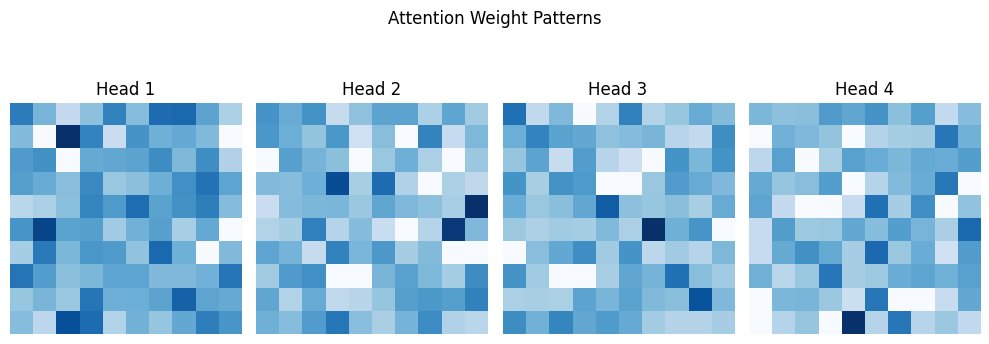

In [11]:
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, num_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k, self.h = d_model // num_heads, num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        Q = self.W_q(Q).view(B, -1, self.h, self.d_k).transpose(1,2)
        K = self.W_k(K).view(B, -1, self.h, self.d_k).transpose(1,2)
        V = self.W_v(V).view(B, -1, self.h, self.d_k).transpose(1,2)
        scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_k)
        if mask is not None: scores = scores.masked_fill(mask==0, -1e9)
        w = self.drop(torch.softmax(scores, dim=-1))
        x = (w @ V).transpose(1,2).contiguous().view(B, -1, self.h*self.d_k)
        return self.W_o(x), w

mha = MultiHeadAttention(d_model=256, num_heads=8).to(device)
x   = torch.randn(2, 10, 256).to(device)
out, attn_weights = mha(x, x, x)
print('Output shape      :', out.shape)          # [2, 10, 256]
print('Attention weights :', attn_weights.shape)  # [2, 8, 10, 10]

# Visualize attention pattern
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(attn_weights[0,i].detach().cpu(), cmap='Blues')
    plt.title(f'Head {i+1}'); plt.axis('off')
plt.suptitle('Attention Weight Patterns'); plt.tight_layout(); plt.show()


### 5.2 Full Transformer Encoder

In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerBlock(nn.Module):
    def __init__(self, d_model=256, heads=8, ff=1024, drop=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, heads, dropout=drop, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, ff), nn.GELU(),
                                   nn.Dropout(drop), nn.Linear(ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(drop)

    def forward(self, x):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab=10000, d=256, heads=8, layers=4, classes=2):
        super().__init__()
        self.embed   = nn.Embedding(vocab, d, padding_idx=0)
        self.pos     = PositionalEncoding(d)
        self.blocks  = nn.ModuleList([TransformerBlock(d, heads) for _ in range(layers)])
        self.norm    = nn.LayerNorm(d)
        self.head    = nn.Linear(d, classes)
        self.scale   = math.sqrt(d)

    def forward(self, x):
        x = self.pos(self.embed(x) * self.scale)
        for blk in self.blocks: x = blk(x)
        return self.head(self.norm(x).mean(dim=1))

model = TransformerClassifier().to(device)
x     = torch.randint(0, 10000, (4, 64)).to(device)
print('Output shape:', model(x).shape)  # [4, 2]
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Output shape: torch.Size([4, 2])
Parameters: 5,720,066


---
# Chapter 6 — Advanced Training Techniques
> *Production-ready: AMP, scheduling, custom losses, checkpointing*

### 6.1 Mixed Precision Training (AMP) + Gradient Clipping

In [13]:
from torch.cuda.amp import autocast, GradScaler

def train_one_epoch_amp(model, loader, optimizer, criterion,
                         device, scaler, max_norm=1.0):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast():                              # FP16 forward
            loss = criterion(model(x), y)
        scaler.scale(loss).backward()                # Scaled backward
        scaler.unscale_(optimizer)                   # Unscale before clip
        nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)

# Train CNN with AMP
cnn        = CNN().to(device)
optimizer  = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler  = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, epochs=3, steps_per_epoch=len(train_loader))
scaler     = GradScaler(enabled=(device=='cuda'))

for epoch in range(3):
    loss = train_one_epoch_amp(cnn, train_loader, optimizer,
                               criterion, device, scaler)
    scheduler.step()
    acc = evaluate(cnn, test_loader)
    lr  = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f} | LR: {lr:.6f}')


/tmp/ipykernel_770/1813550834.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler(enabled=(device=='cuda'))
/tmp/ipykernel_770/1813550834.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                              # FP16 forward


Epoch 1 | Loss: 1.0603 | Acc: 0.9267 | LR: 0.000040
Epoch 2 | Loss: 0.2652 | Acc: 0.9637 | LR: 0.000040
Epoch 3 | Loss: 0.1563 | Acc: 0.9753 | LR: 0.000040


### 6.2 Custom Loss Functions

In [14]:
# Focal Loss — great for class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        return (self.alpha * (1-pt)**self.gamma * ce).mean()

# Label Smoothing Loss
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=10, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.cls = classes
    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)
        smooth_target = torch.full_like(pred, smooth_val)
        smooth_target.scatter_(1, target.unsqueeze(1), confidence)
        return F.kl_div(F.log_softmax(pred, dim=1),
                        smooth_target, reduction='batchmean')

# Compare losses on a batch
logits = torch.randn(16, 10)
labels = torch.randint(0, 10, (16,))
print(f'CrossEntropy  : {nn.CrossEntropyLoss()(logits, labels):.4f}')
print(f'FocalLoss     : {FocalLoss()(logits, labels):.4f}')
print(f'LabelSmoothing: {LabelSmoothingLoss()(logits, labels):.4f}')


CrossEntropy  : 2.8435
FocalLoss     : 2.5039
LabelSmoothing: 2.2829


### 6.3 Checkpointing & Model Export

In [15]:
import os

def save_checkpoint(model, optimizer, epoch, loss, path='/tmp/checkpoint.pt'):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)
    print(f'✅ Saved checkpoint → {path}')

def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    print(f'✅ Loaded from epoch {ckpt["epoch"]} | loss={ckpt["loss"]:.4f}')
    return ckpt['epoch']

# Save & reload the CNN
save_checkpoint(cnn, optimizer, epoch=3, loss=0.05)
fresh_model = CNN().to(device)
load_checkpoint('/tmp/checkpoint.pt', fresh_model)

# TorchScript export (for production)
fresh_model.eval()
scripted = torch.jit.script(fresh_model)
scripted.save('/tmp/model_scripted.pt')
loaded = torch.jit.load('/tmp/model_scripted.pt')
print('TorchScript export OK:', loaded(torch.randn(1,1,28,28).to(device)).shape)

# ONNX export (for deployment across frameworks)
dummy = torch.randn(1, 1, 28, 28).to(device)
torch.onnx.export(fresh_model, dummy, '/tmp/model.onnx',
                  input_names=['image'], output_names=['logits'],
                  dynamic_axes={'image': {0: 'batch'}})
print('ONNX export OK → /tmp/model.onnx')


✅ Saved checkpoint → /tmp/checkpoint.pt
✅ Loaded from epoch 3 | loss=0.0500
TorchScript export OK: torch.Size([1, 10])


ModuleNotFoundError: No module named 'onnxscript'

---
## 🎓 What's Next?

| Topic | What to Explore |
|---|---|
| **Vision** | ResNet, EfficientNet, ViT, YOLO |
| **NLP** | BERT fine-tuning, GPT-2, HuggingFace Transformers |
| **Generative** | VAE, GAN, Diffusion Models |
| **Reinforcement** | DQN, PPO with `stable-baselines3` |
| **Graph** | GCN, GAT with PyTorch Geometric |
| **Speed** | `torch.compile`, Triton kernels, `bfloat16` |
